# 02: Training pipeline

This notebook trains the MLP, GNN and hybrid models using the same dataset and the same multi-task objective.

The complete path followed by one batch is:

`saved samples → Dataset → DataLoader → padded tensors → model → loss → backward pass → optimizer step`

The code is kept explicit so that the main PyTorch operations can be followed directly.

In [1]:
import copy
import json
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from sklearn.metrics import average_precision_score, f1_score
from torch import nn
from torch.utils.data import DataLoader, Dataset


## Import the model definitions

`dl_models.py` contains the model classes developed in `01_models.ipynb`. Importing them avoids redefining the architectures in every notebook.

In [2]:
from dl_models import (
    GNNPredictor,
    HybridGNNTransformer,
    MLPBaseline,
    build_model,
)


## Paths, configuration and reproducibility

The YAML file stores experiment choices such as hidden dimensions, learning rate, batch size and number of epochs. Keeping these values outside the code makes experiments easier to repeat.

In [3]:
current_folder = Path.cwd().resolve()

# Usually the notebook is run directly from the DL_project folder.
if (current_folder / "config.yaml").exists():
    ROOT = current_folder

# This alternative also allows the notebook to be run from its parent folder.
elif (current_folder / "DL_project" / "config.yaml").exists():
    ROOT = current_folder / "DL_project"

elif (current_folder.parent / "config.yaml").exists():
    ROOT = current_folder.parent

else:
    raise FileNotFoundError("config.yaml was not found. Run the notebook from the DL_project folder.")

with (ROOT / "config.yaml").open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

DATA_DIR = ROOT / config["data"]["output_dir"]
CHECKPOINT_DIR = ROOT / "artifacts" / "checkpoints"
HISTORY_DIR = ROOT / "artifacts" / "histories"
FIGURE_DIR = ROOT / "artifacts" / "results" / "figures"

for folder in [CHECKPOINT_DIR, HISTORY_DIR, FIGURE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)


Project root: /home/riccorte/CIRCLES/DL/DL_project


In [4]:
SEED = int(config["seed"])

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)


Device: cpu


## Load the dataset

`torch.load` reconstructs the tensors and dictionaries saved by `00_dataset.ipynb`. The train and validation sets are loaded here, while the test set remains unused until the evaluation notebook.

In [5]:
train_path = DATA_DIR / "train.pt"
validation_path = DATA_DIR / "val.pt"
test_path = DATA_DIR / "test.pt"
metadata_path = DATA_DIR / "metadata.json"

required_paths = [
    train_path,
    validation_path,
    test_path,
    metadata_path,
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run 00_dataset.ipynb first.")

# weights_only=False is needed because these files contain full Python
# dictionaries of tensors rather than only a model state dictionary.
train_samples = torch.load(
    train_path,
    map_location="cpu",
    weights_only=False,
)
validation_samples = torch.load(
    validation_path,
    map_location="cpu",
    weights_only=False,
)

metadata = json.loads(
    metadata_path.read_text(encoding="utf-8")
)

print("Training samples:", len(train_samples))
print("Validation samples:", len(validation_samples))
print("Metadata:", metadata)


Training samples: 1912
Validation samples: 403
Metadata: {'feature_dim': 11, 'lap_pe_dim': 8, 'max_nodes': 40, 'split_sizes': {'train': 1912, 'val': 403, 'test': 413}, 'graph_ids': {'train': [0, 1, 2, 3, 4, 5, 6, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25, 26, 28, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 47, 49, 51, 54, 55, 56, 57, 58, 60, 61, 63, 64, 65, 66, 69, 70, 71, 74, 75, 76, 79, 80, 81, 82, 86, 87, 88, 90, 91, 92, 93, 96, 97, 98, 99, 100, 101, 103, 105, 106, 107, 108, 109, 110, 111, 113, 114, 115, 116, 117, 118, 121, 123, 125, 126, 127, 128, 129, 130, 133, 135, 136, 139, 140, 142, 144, 146, 148, 149, 150, 151, 154, 155, 156, 157, 159, 160, 162, 163, 165, 166, 167, 169, 171, 172, 174, 175, 176, 177, 182, 184, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 199, 202, 203, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 222, 223, 225, 226, 228, 229, 231, 233, 234, 237, 239, 241, 245, 247, 248, 250, 251, 252, 253

## PyTorch `Dataset`

A `Dataset` tells PyTorch how many samples are available and how to retrieve one sample by index. It does not yet create batches.

In [6]:
class CascadeDataset(Dataset):
    def __init__(self, samples_or_path):
        if isinstance(samples_or_path, (str, Path)):
            self.samples = torch.load(
                samples_or_path,
                map_location="cpu",
                weights_only=False,
            )
        else:
            self.samples = list(samples_or_path)

        if len(self.samples) == 0:
            raise ValueError("The dataset is empty.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        return self.samples[index]


## Padded graph batches

Graphs can contain different numbers of nodes. A normal tensor must have one rectangular shape, so smaller graphs are padded to the largest graph in the current batch.

The boolean `mask` is `True` for real nodes and `False` for padding. The GNN and the loss function use it to ignore the artificial entries.

In [7]:
def collate_graph_batch(samples):
    batch_size = len(samples)

    # The batch is padded only up to the largest graph currently present.
    max_nodes = max(
        int(sample["num_nodes"])
        for sample in samples
    )

    feature_dim = int(samples[0]["x"].shape[1])
    positional_dim = int(samples[0]["lap_pe"].shape[1])
    max_distance = int(config["data"]["max_distance"])

    # Preallocate all tensors with zeros, then copy each graph into them.
    batch_x = torch.zeros(
        batch_size,
        max_nodes,
        feature_dim,
    )
    batch_adjacency = torch.zeros(
        batch_size,
        max_nodes,
        max_nodes,
    )
    batch_lap_pe = torch.zeros(
        batch_size,
        max_nodes,
        positional_dim,
    )

    # max_distance + 1 is used as the padding/unreachable distance class.
    batch_distance = torch.full(
        (batch_size, max_nodes, max_nodes),
        fill_value=max_distance + 1,
        dtype=torch.long,
    )

    batch_mask = torch.zeros(
        batch_size,
        max_nodes,
        dtype=torch.bool,
    )
    batch_y_node = torch.zeros(
        batch_size,
        max_nodes,
    )
    batch_y_load = torch.zeros(
        batch_size,
        max_nodes,
    )
    batch_y_graph = torch.zeros(batch_size)

    batch_metadata = []

    for batch_index, sample in enumerate(samples):
        num_nodes = int(sample["num_nodes"])

        batch_x[batch_index, :num_nodes] = sample["x"]
        batch_adjacency[
            batch_index,
            :num_nodes,
            :num_nodes,
        ] = sample["adj"]
        batch_lap_pe[
            batch_index,
            :num_nodes,
        ] = sample["lap_pe"]
        batch_distance[
            batch_index,
            :num_nodes,
            :num_nodes,
        ] = sample["dist"]

        batch_mask[batch_index, :num_nodes] = True
        batch_y_node[
            batch_index,
            :num_nodes,
        ] = sample["y_node"]
        batch_y_load[
            batch_index,
            :num_nodes,
        ] = sample["y_load"]
        batch_y_graph[batch_index] = sample["y_graph"]

        batch_metadata.append(
            {
                "num_nodes": num_nodes,
                "graph_id": int(sample["graph_id"]),
                "family": sample["family"],
                "regime": sample["regime"],
            }
        )

    return {
        "x": batch_x,
        "adj": batch_adjacency,
        "lap_pe": batch_lap_pe,
        "dist": batch_distance,
        "mask": batch_mask,
        "y_node": batch_y_node,
        "y_load": batch_y_load,
        "y_graph": batch_y_graph,
        "metadata": batch_metadata,
    }


## PyTorch `DataLoader`

The `DataLoader` asks the dataset for several samples, optionally shuffles them, and passes the list to `collate_graph_batch`.

The seeded `torch.Generator` makes the training shuffle repeatable.

Here we are training using minibatches.

In [8]:
def make_loader(samples, batch_size, shuffle):
    dataset = CascadeDataset(samples)

    shuffle_generator = None
    if shuffle:
        shuffle_generator = torch.Generator()
        shuffle_generator.manual_seed(SEED)

    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collate_graph_batch,
        generator=shuffle_generator,
    )

    return loader


batch_size = int(config["training"]["batch_size"])

train_loader = make_loader(
    train_samples,
    batch_size=batch_size,
    shuffle=True,
)
validation_loader = make_loader(
    validation_samples,
    batch_size=batch_size,
    shuffle=False,
)


In [9]:
# Inspecting one batch is an easy way to check the padding logic.
example_batch = next(iter(train_loader))

for key, value in example_batch.items():
    if torch.is_tensor(value):
        print(
            f"{key:10s}",
            "shape =", tuple(value.shape),
            "dtype =", value.dtype,
        )


x          shape = (16, 40, 11) dtype = torch.float32
adj        shape = (16, 40, 40) dtype = torch.float32
lap_pe     shape = (16, 40, 8) dtype = torch.float32
dist       shape = (16, 40, 40) dtype = torch.int64
mask       shape = (16, 40) dtype = torch.bool
y_node     shape = (16, 40) dtype = torch.float32
y_load     shape = (16, 40) dtype = torch.float32
y_graph    shape = (16,) dtype = torch.float32


## Move a batch to the selected device

A model and its input tensors must be on the same device. Metadata remains as ordinary Python objects and is therefore not moved.

In [10]:
def move_batch_to_device(batch, device):
    moved_batch = {}

    for key, value in batch.items():
        if torch.is_tensor(value):
            moved_batch[key] = value.to(device)
        else:
            moved_batch[key] = value

    return moved_batch


## Class imbalance and multi-task loss

Failed nodes are less common than non-failed nodes. `pos_weight` increases the contribution of positive examples inside the binary cross-entropy.

The complete objective combines:

- node-failure classification;
- next-load regression;
- graph-level cascade-size regression.

In [11]:
def estimate_positive_weight(loader):
    number_of_positives = 0.0
    number_of_labels = 0.0

    for batch in loader:
        # Boolean indexing keeps only real nodes.
        valid_targets = batch["y_node"][batch["mask"]]

        number_of_positives += float(valid_targets.sum())
        number_of_labels += float(valid_targets.numel())

    number_of_negatives = number_of_labels - number_of_positives

    positive_weight = number_of_negatives / max(
        number_of_positives,
        1.0,
    )

    return torch.tensor(
        positive_weight,
        dtype=torch.float32,
    )


In [12]:
def compute_multitask_loss(outputs, batch, positive_weight, training_config):
    mask = batch["mask"]

    # This function combines sigmoid and binary cross-entropy in a stable way.
    node_loss = nn.functional.binary_cross_entropy_with_logits(
        outputs["node_logits"][mask],
        batch["y_node"][mask],
        pos_weight=positive_weight,
    )

    load_loss = nn.functional.mse_loss(
        outputs["load_pred"][mask],
        batch["y_load"][mask],
    )

    graph_loss = nn.functional.mse_loss(
        outputs["graph_pred"],
        batch["y_graph"],
    )

    node_weight = float(training_config["node_loss_weight"])
    load_weight = float(training_config["load_loss_weight"])
    graph_weight = float(training_config["graph_loss_weight"])

    total_loss = (
        node_weight * node_loss
        + load_weight * load_loss
        + graph_weight * graph_loss
    )

    return {
        "loss": total_loss,
        "node_loss": node_loss,
        "load_loss": load_loss,
        "graph_loss": graph_loss,
    }


## One-batch training check

This small test performs exactly one optimizer step for every architecture. It verifies the full PyTorch chain before a long training run:

`zero gradients → forward pass → loss → backward pass → parameter update`.

In [13]:
positive_weight = estimate_positive_weight(train_loader).to(device)

print(
    "Positive-class weight:",
    float(positive_weight),
)

sanity_rows = []

for model_name in ["mlp", "gnn", "hybrid"]:
    model = build_model(
        model_name,
        metadata,
        config,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-3,
    )

    batch = next(iter(train_loader))
    batch = move_batch_to_device(batch, device)

    # Gradients accumulate in PyTorch, so they must be cleared first.
    optimizer.zero_grad()

    outputs = model(batch)
    losses = compute_multitask_loss(
        outputs,
        batch,
        positive_weight,
        config["training"],
    )

    # backward() uses autograd to calculate d(loss)/d(parameter).
    losses["loss"].backward()

    squared_gradient_sum = torch.tensor(
        0.0,
        device=device,
    )

    for parameter in model.parameters():
        if parameter.grad is not None:
            squared_gradient_sum += (
                parameter.grad.detach().pow(2).sum()
            )

    gradient_norm = torch.sqrt(squared_gradient_sum)

    # step() updates every parameter using its current gradient.
    optimizer.step()

    sanity_rows.append(
        {
            "model": model_name,
            "loss": float(
                losses["loss"].detach()
            ),
            "gradient_norm": float(gradient_norm),
        }
    )

pd.DataFrame(sanity_rows)


Positive-class weight: 1.7294789552688599


,model,loss,gradient_norm
0,mlp,1.179521,0.247170
1,gnn,1.109512,1.228778
2,hybrid,1.082267,0.967903


## Metrics used during training

PR-AUC is useful for an imbalanced classification problem because it focuses on the ranking of positive cases. F1 is reported at the temporary threshold `0.5`; the final threshold will be selected using validation data in the evaluation notebook.

In [14]:
def safe_pr_auc(targets, scores):
    # PR-AUC is undefined when the target contains only one class.
    if len(np.unique(targets)) < 2:
        return float("nan")

    return float(
        average_precision_score(
            targets,
            scores,
        )
    )


## One complete epoch

`model.train()` enables training behaviour such as dropout. `model.eval()` disables dropout for validation.

`torch.set_grad_enabled(training)` tells PyTorch to build the autograd graph only when an optimizer step will actually be performed.

In [15]:
def run_epoch(
    model,
    loader,
    device,
    training_config,
    positive_weight,
    optimizer=None,
):
    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    total_loss_values = {
        "loss": 0.0,
        "node_loss": 0.0,
        "load_loss": 0.0,
        "graph_loss": 0.0,
    }

    all_node_targets = []
    all_node_scores = []
    all_graph_targets = []
    all_graph_predictions = []

    number_of_batches = 0

    for batch in loader:
        batch = move_batch_to_device(
            batch,
            device,
        )

        if training:
            optimizer.zero_grad()

        # Validation does not need gradient storage.
        with torch.set_grad_enabled(training):
            outputs = model(batch)

            losses = compute_multitask_loss(
                outputs,
                batch,
                positive_weight,
                training_config,
            )

            if training:
                losses["loss"].backward()

                # Gradient clipping limits unusually large updates.
                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=float(training_config["gradient_clip"]),
                )

                optimizer.step()

        for loss_name in total_loss_values:
            total_loss_values[loss_name] += float(
                losses[loss_name].detach()
            )

        number_of_batches += 1

        mask = batch["mask"]

        node_targets = batch["y_node"][mask].detach().cpu().numpy()
        node_scores = torch.sigmoid(outputs["node_logits"][mask]).detach().cpu().numpy()

        all_node_targets.append(node_targets)
        all_node_scores.append(node_scores)

        all_graph_targets.append(
            batch["y_graph"].detach().cpu().numpy()
        )
        all_graph_predictions.append(
            outputs["graph_pred"].detach().cpu().numpy()
        )

    targets = np.concatenate(all_node_targets)
    scores = np.concatenate(all_node_scores)
    graph_targets = np.concatenate(all_graph_targets)
    graph_predictions = np.concatenate(all_graph_predictions)

    metrics = {}

    for loss_name, accumulated_value in total_loss_values.items():
        metrics[loss_name] = (
            accumulated_value
            / max(number_of_batches, 1)
        )

    metrics["f1"] = float(
        f1_score(
            targets,
            scores >= 0.5,
            zero_division=0,
        )
    )
    metrics["pr_auc"] = safe_pr_auc(
        targets,
        scores,
    )
    metrics["graph_mae"] = float(
        np.mean(
            np.abs(
                graph_targets
                - graph_predictions
            )
        )
    )

    return metrics


## Early stopping and checkpoints

After every epoch, validation performance is checked. When it improves, a copy of the current `state_dict` is stored in memory.

A `state_dict` is a dictionary containing the learnable PyTorch tensors of the model. Saving it is the standard way to store trained weights.

In [16]:
def metric_is_better(current_value, best_value, metric_name):
    metrics_to_minimize = {
        "loss",
        "graph_mae",
        "graph_rmse",
    }

    if metric_name in metrics_to_minimize:
        return current_value < best_value

    return current_value > best_value


In [17]:
def train_model(model_name, train_loader, validation_loader):
    model = build_model(
        model_name,
        metadata,
        config,
    ).to(device)

    training_config = config["training"]

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(training_config["learning_rate"]),
        weight_decay=float(training_config["weight_decay"]),
    )

    local_positive_weight = estimate_positive_weight(train_loader).to(device)

    monitored_metric = str(
        training_config.get(
            "monitor",
            "pr_auc",
        )
    )

    if monitored_metric in {
        "loss",
        "graph_mae",
        "graph_rmse",
    }:
        best_value = math.inf
    else:
        best_value = -math.inf

    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0
    history = []

    start_time = time.perf_counter()

    maximum_epochs = int(training_config["epochs"])
    patience = int(training_config["patience"])

    for epoch in range(
        1,
        maximum_epochs + 1,
    ):
        train_metrics = run_epoch(
            model=model,
            loader=train_loader,
            device=device,
            training_config=training_config,
            positive_weight=local_positive_weight,
            optimizer=optimizer,
        )

        validation_metrics = run_epoch(
            model=model,
            loader=validation_loader,
            device=device,
            training_config=training_config,
            positive_weight=local_positive_weight,
            optimizer=None,
        )

        history.append(
            {
                "epoch": epoch,
                "train": train_metrics,
                "val": validation_metrics,
            }
        )

        print(
            f"{model_name:6s} "
            f"epoch={epoch:02d} "
            f"train_loss={train_metrics['loss']:.4f} "
            f"val_loss={validation_metrics['loss']:.4f} "
            f"val_f1={validation_metrics['f1']:.3f} "
            f"val_pr_auc={validation_metrics['pr_auc']:.3f}"
        )

        current_value = validation_metrics[
            monitored_metric
        ]

        improved = (
            np.isfinite(current_value)
            and metric_is_better(
                current_value,
                best_value,
                monitored_metric,
            )
        )

        if improved:
            best_value = current_value
            best_epoch = epoch
            epochs_without_improvement = 0

            # deepcopy is necessary because state_dict tensors would otherwise
            # continue changing while the model trains.
            best_state = copy.deepcopy(
                model.state_dict()
            )

        else:
            epochs_without_improvement += 1

            if (
                epochs_without_improvement
                >= patience
            ):
                print(
                    f"{model_name}: early stopping "
                    f"at epoch {epoch}."
                )
                break

    if best_state is None:
        best_state = copy.deepcopy(
            model.state_dict()
        )
        best_epoch = len(history)

    # Return the model to its best validation state.
    model.load_state_dict(best_state)

    elapsed_seconds = (
        time.perf_counter()
        - start_time
    )

    checkpoint = {
        "model_name": model_name,
        "model_state": best_state,
        "metadata": metadata,
        "config": config,
        "best_epoch": best_epoch,
        "best_monitor_value": best_value,
        "elapsed_seconds": elapsed_seconds,
    }

    checkpoint_path = (
        CHECKPOINT_DIR
        / f"{model_name}.pt"
    )
    torch.save(
        checkpoint,
        checkpoint_path,
    )

    history_path = (
        HISTORY_DIR
        / f"{model_name}.json"
    )
    history_path.write_text(
        json.dumps(
            history,
            indent=2,
        ),
        encoding="utf-8",
    )

    return model, history, checkpoint


## Train the three architectures

The models are trained sequentially so that they use the same data splits and experiment configuration.

In [18]:
training_results = {}

for model_name in [
    "mlp",
    "gnn",
    "hybrid",
]:
    trained_model, history, checkpoint = train_model(
        model_name,
        train_loader,
        validation_loader,
    )

    training_results[model_name] = {
        "model": trained_model,
        "history": history,
        "checkpoint": checkpoint,
    }


mlp    epoch=01 train_loss=0.8583 val_loss=0.7449 val_f1=0.683 val_pr_auc=0.784
mlp    epoch=02 train_loss=0.6844 val_loss=0.7245 val_f1=0.709 val_pr_auc=0.793
mlp    epoch=03 train_loss=0.6389 val_loss=0.7382 val_f1=0.713 val_pr_auc=0.797
mlp    epoch=04 train_loss=0.5958 val_loss=0.7511 val_f1=0.710 val_pr_auc=0.803
mlp    epoch=05 train_loss=0.5567 val_loss=0.7267 val_f1=0.719 val_pr_auc=0.807
mlp    epoch=06 train_loss=0.5263 val_loss=0.7711 val_f1=0.708 val_pr_auc=0.804
mlp    epoch=07 train_loss=0.4976 val_loss=0.7303 val_f1=0.721 val_pr_auc=0.812
mlp    epoch=08 train_loss=0.4786 val_loss=0.7227 val_f1=0.725 val_pr_auc=0.813
mlp    epoch=09 train_loss=0.4566 val_loss=0.7322 val_f1=0.726 val_pr_auc=0.814
mlp    epoch=10 train_loss=0.4421 val_loss=0.7612 val_f1=0.726 val_pr_auc=0.815
mlp    epoch=11 train_loss=0.4231 val_loss=0.7571 val_f1=0.730 val_pr_auc=0.821
mlp    epoch=12 train_loss=0.4115 val_loss=0.7709 val_f1=0.726 val_pr_auc=0.817
mlp    epoch=13 train_loss=0.3986 val_lo

In [19]:
summary_rows = []

for model_name, result in training_results.items():
    checkpoint = result["checkpoint"]

    summary_rows.append(
        {
            "model": model_name,
            "best_epoch": checkpoint["best_epoch"],
            "best_validation_metric": checkpoint[
                "best_monitor_value"
            ],
            "training_seconds": checkpoint[
                "elapsed_seconds"
            ],
        }
    )

training_summary = pd.DataFrame(summary_rows)

training_summary


,model,best_epoch,best_validation_metric,training_seconds
0,mlp,11,0.820782,41.053974
1,gnn,74,0.989275,382.229189
2,hybrid,35,0.990460,1035.364845


## Learning curves

The first figure shows the combined validation loss. The second shows node-failure PR-AUC. A widening difference between training and validation curves can indicate overfitting.

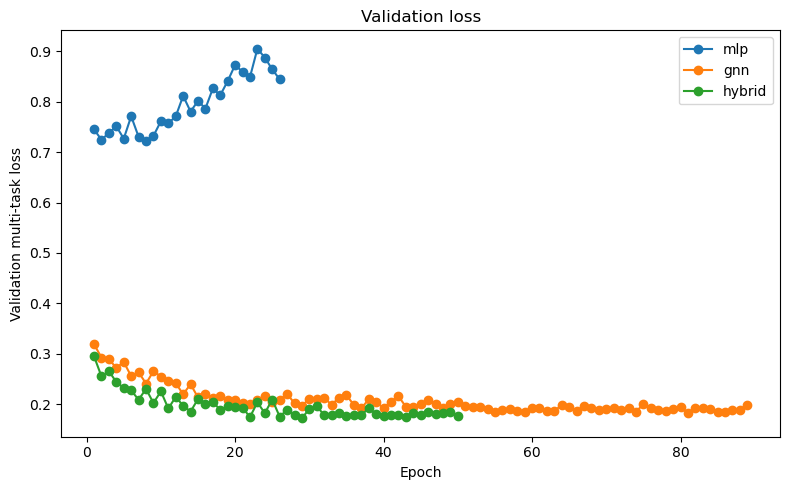

In [20]:
plt.figure(figsize=(8, 5))

for model_name, result in training_results.items():
    epochs = []
    validation_losses = []

    for record in result["history"]:
        epochs.append(record["epoch"])
        validation_losses.append(record["val"]["loss"])

    plt.plot(
        epochs,
        validation_losses,
        marker="o",
        label=model_name,
    )

plt.xlabel("Epoch")
plt.ylabel("Validation multi-task loss")
plt.title("Validation loss")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "training_validation_loss.png",
    dpi=180,
)

plt.show()


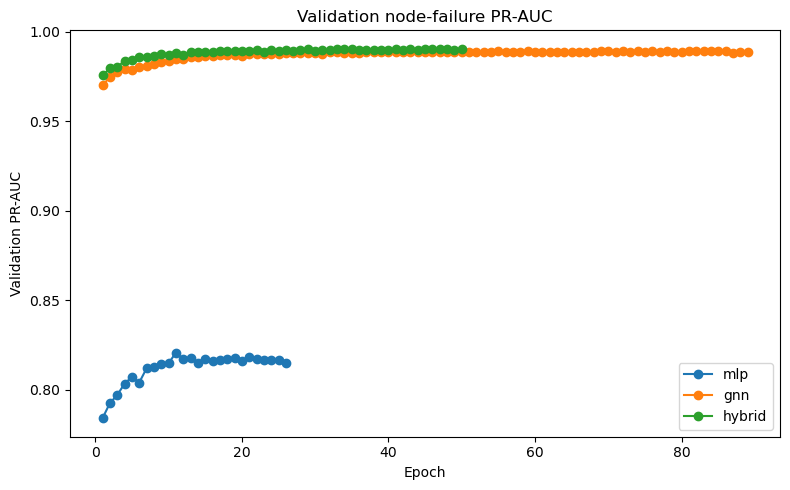

In [21]:
plt.figure(figsize=(8, 5))

for model_name, result in training_results.items():
    epochs = []
    validation_pr_auc = []

    for record in result["history"]:
        epochs.append(record["epoch"])
        validation_pr_auc.append(record["val"]["pr_auc"])

    plt.plot(
        epochs,
        validation_pr_auc,
        marker="o",
        label=model_name,
    )

plt.xlabel("Epoch")
plt.ylabel("Validation PR-AUC")
plt.title("Validation node-failure PR-AUC")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "training_validation_pr_auc.png",
    dpi=180,
)

plt.show()


The checkpoint of each model contains the parameters from its best validation epoch, not necessarily from its final epoch. The test set is still untouched and will be used only in `03_evaluation.ipynb`.